# 04 Biological collection comparison

            Compare Hallmark, Reactome, combined canonical pathways and GO Biological
            Process using identical saved gene contributions within each fold.
            GO groups functions, not exclusively reaction pathways. Canonical
            pathways include Reactome and do not provide independent replication.

            This records the completed four-collection comparison. GO results
            can be read directly in the saved comparison below. See the
            [comparison results](../../results/published/group_comparison/RESULTS.md).

In [1]:
from pathlib import Path
import json
from IPython.display import Markdown, Image, display

current = Path.cwd().resolve()
STUDY = next(p for p in (current, *current.parents)
             if (p / "results/published").is_dir())
RESULTS = STUDY / "results/published"

def read_json(relative):
    path = (RESULTS / relative).resolve()
    if not path.is_relative_to(RESULTS.resolve()) or path.suffix != ".json":
        raise ValueError("Only published JSON summaries may be read")
    return json.loads(path.read_text())

def table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

print("Review mode: included aggregate results only; no training or participant-table access.")

Review mode: included aggregate results only; no training or participant-table access.


| Collection | Genes covered | Gene coverage | Attribution coverage |
| --- | --- | --- | --- |
| Hallmark | 4211 | 24.4% | 23.5% |
| Reactome | 10025 | 58.1% | 56.8% |
| Canonical pathways | 11961 | 69.3% | 68.2% |
| GO Biological Process | 14677 | 85.0% | 84.2% |

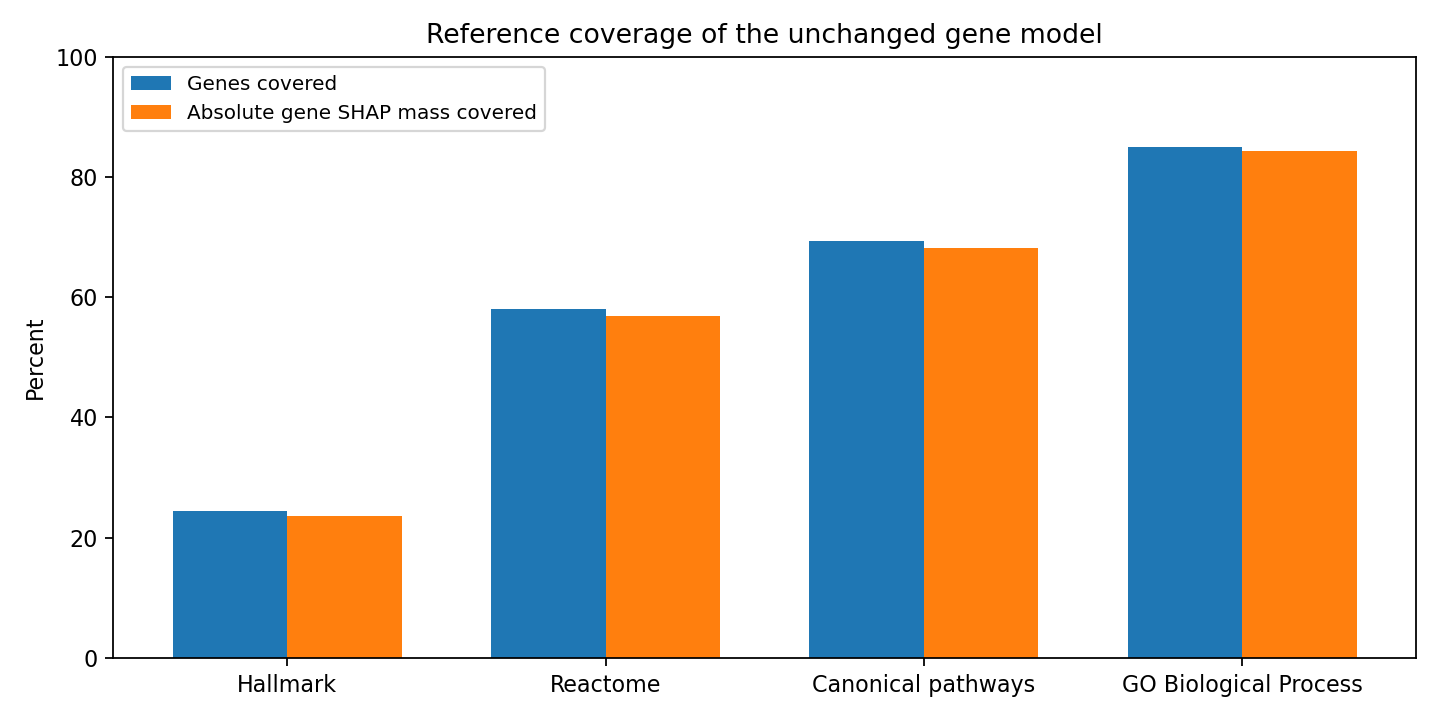

In [2]:
comparison = read_json("group_comparison/comparison.json")
primary = [r for r in comparison if r["size_rule"] == "primary"]
table(["Collection", "Genes covered", "Gene coverage", "Attribution coverage"], [
    [r["label"], r["covered_gene_count"], f'{r["covered_gene_fraction"]:.1%}',
     f'{r["covered_absolute_gene_attribution_fraction"]:.1%}'] for r in primary])
display(Image(filename=str(RESULTS / "group_comparison/coverage.png")))

## Consistency against randomized groups

            Top-five agreement measures how much the group lists share across
            folds: 0 means no shared names; 1 means identical lists. There is no
            medical pass mark. Each collection is compared with 100 random
            covered-gene relabellings preserving group sizes and intersections.

            We also specified a 15–500 measured-gene size restriction before this
            comparison. It is a sensitivity rule, not a validated XAI threshold.
            Both analyses are retained; Hallmark's identical memberships reuse results.

| Collection | Size rule | Real agreement | Random mean |
| --- | --- | --- | --- |
| Hallmark | primary | 0.335 | 0.325 |
| Hallmark | size_15_500 | 0.335 | 0.325 |
| Reactome | primary | 0.800 | 0.620 |
| Reactome | size_15_500 | 0.500 | 0.505 |
| Canonical pathways | primary | 0.595 | 0.535 |
| Canonical pathways | size_15_500 | 0.533 | 0.422 |
| GO Biological Process | primary | 0.464 | 0.548 |
| GO Biological Process | size_15_500 | 0.349 | 0.398 |

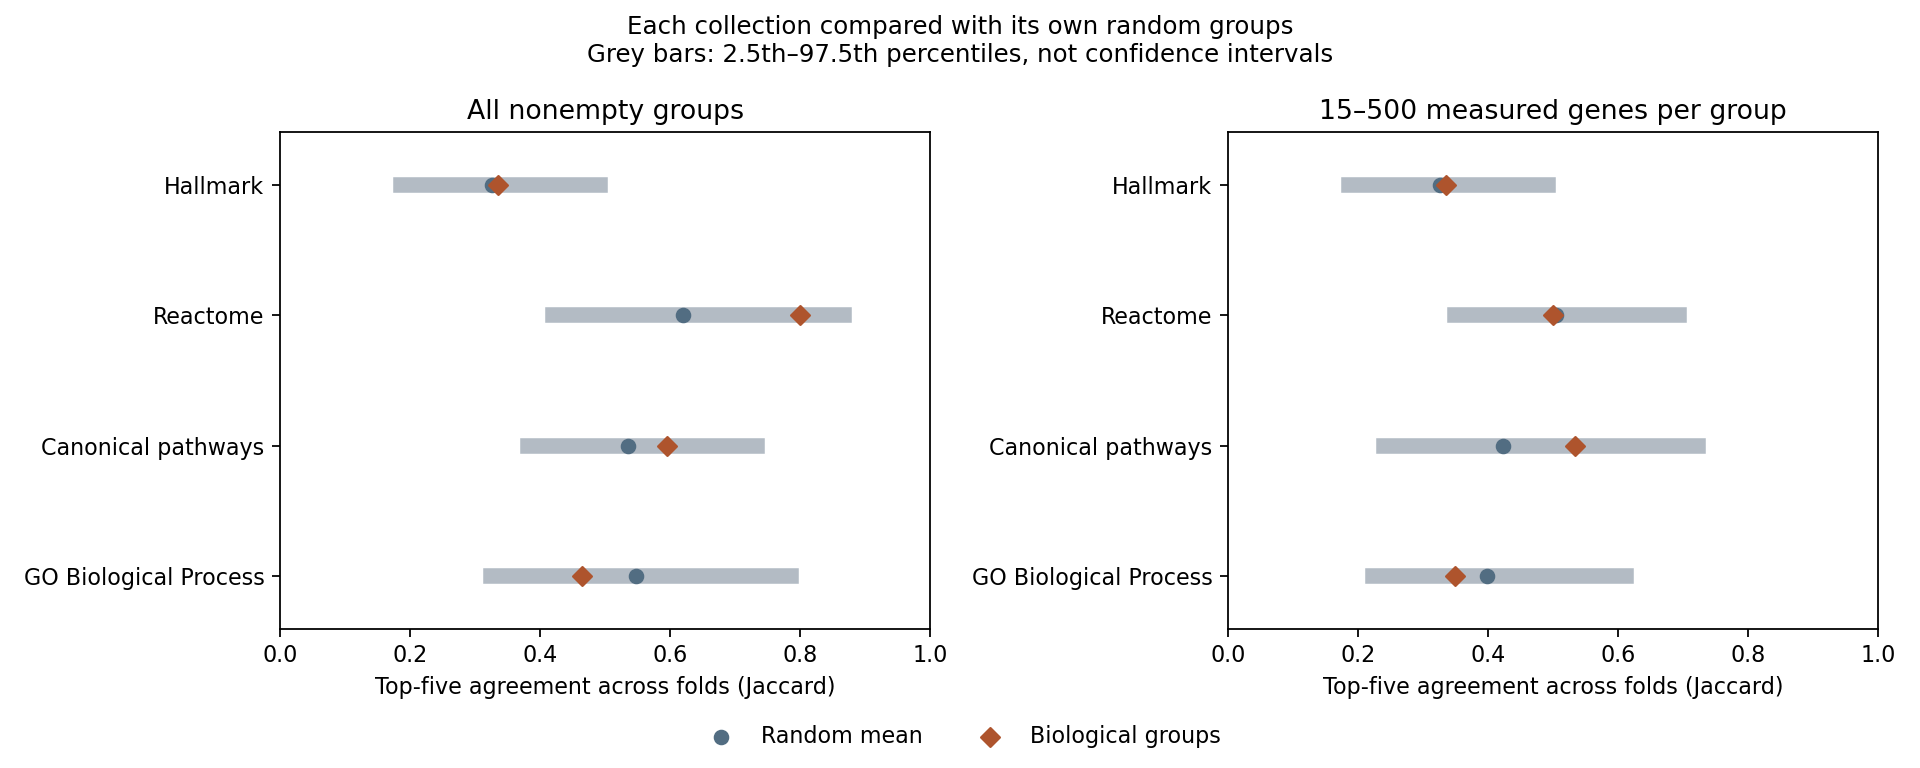

In [3]:
table(["Collection", "Size rule", "Real agreement", "Random mean"], [
    [r["label"], r["size_rule"], f'{r["observed"]["mean_pathway_jaccard"]:.3f}',
     f'{r["random_control_comparison"]["mean_pathway_jaccard"]["random_mean"]:.3f}']
    for r in comparison])
display(Image(filename=str(RESULTS / "group_comparison/group_stability.png")))

## Conclusion

            GO increases gene coverage to 85.0% but does not show higher agreement
            than its randomized reference. Reactome initially looks more consistent,
            but its advantage disappears under the predefined size rule. That rule
            changes both group availability and contribution-sharing weights, so
            it does not isolate size as the sole cause.

            The result is not proof that pathways are medically irrelevant or
            equivalent to random groups. It shows that broader coverage does not
            establish better explanations in this experiment. Different validation
            records, fitted settings, correlated genes and blood confounding remain.

            The 26.0% covered-gene membership means an average of 5.2 of the top
            20 GO-covered genes occurred in the five leading groups. All 20 genes
            have an annotation somewhere in GO; this is not 26.0% annotation coverage.

            [Plain-language interpretation](../../results/published/group_comparison/INTERPRETATION.md),
            [full results](../../results/published/group_comparison/RESULTS.md),
            [comparison plan](../../src/asd_blood/comparison_plan.md) and [sources](../../data/reference/REFERENCES.md).